# **Chest X-Ray YOLO Model Training Example**

This notebook is an example demonstrating how to load and explore the Chest X-ray dataset used for training a Deep Learning model. The dataset comprises 112,120 frontal-view X-ray images from 30,805 unique patients. Each image may have multi-label annotations for the following fourteen thoracic pathologies:

- Atelectasis
- Consolidation
- Infiltration
- Pneumothorax
- Edema
- Emphysema
- Fibrosis
- Effusion
- Pneumonia
- Pleural Thickening
- Cardiomegaly
- Nodule
- Mass
- Hernia

The focus of this notebook is solely on data loading and preliminary exploration.

# Clean environment

In [ ]:
!rm -rf sample_data

# Libraries

If you're using Google Colab, just run the next cell. If you're using a local notebook (e.g., inside of VSC), change the cell language mode to Batch or similar.

In [32]:
!pip install huggingface_hub pandas

# Getting the dataset

You can either use the complete dataset (more than 40 GB will be needed) or a 17 GB dataset created from the original that is stored on Google Drive and can be mounted in order to load it quickly.

**Important**: The download size of the complete dataset is around 17 GB.

In [142]:
import pandas as pd
import os
import zipfile
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from glob import glob
from itertools import chain
from matplotlib import pyplot as plt

In [49]:
HUGGING_FACE = "hugging_face"
GOOGLE_DRIVE = "google_drive"

# Modify this variable to change the dataset download mode
DATASET_DOWNLOAD_MODE = HUGGING_FACE

if DATASET_DOWNLOAD_MODE == HUGGING_FACE:
    from huggingface_hub import hf_hub_download

    REPO_ID = "alkzar90/NIH-Chest-X-ray-dataset"
    FILEPATH = "data/Data_Entry_2017_v2020.csv"

    datasets_path = Path("datasets/").mkdir(exist_ok=True)
    dataset_path = Path(hf_hub_download(repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

    # Download images
    for i in range(1, 4+1):
        FILEPATH = f"data/images/images_{i:03d}.zip"

        print(f"Downloading {FILEPATH}...")
        zip_path = Path(hf_hub_download(
            repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

        zipfile.ZipFile(zip_path).extractall("datasets/data/")
        os.system(f"rm datasets/{FILEPATH}")

        print("ZIP extracted and removed!")

    print("Dataset downloaded!")

# TODO: Implement Google Drive mount
# elif DATASET_DOWNLOAD_MODE == GOOGLE_DRIVE:
#     from google.colab import drive
#     drive.mount('/content/drive')

# Data Exploration

In [ ]:
!ls datasets/data/images

00000001_000.png  00001854_004.png  00003611_007.png  00005609_009.png	00007301_002.png
00000001_001.png  00001855_000.png  00003612_000.png  00005609_010.png	00007301_003.png
00000001_002.png  00001855_001.png  00003613_000.png  00005609_011.png	00007301_004.png
00000002_000.png  00001855_002.png  00003614_000.png  00005609_012.png	00007301_005.png
00000003_000.png  00001855_003.png  00003615_000.png  00005609_013.png	00007302_000.png
00000003_001.png  00001855_004.png  00003615_001.png  00005609_014.png	00007303_000.png
00000003_002.png  00001855_005.png  00003615_002.png  00005609_015.png	00007303_001.png
00000003_003.png  00001855_006.png  00003616_000.png  00005609_016.png	00007303_002.png
00000003_004.png  00001855_007.png  00003617_000.png  00005609_017.png	00007303_003.png
00000003_005.png  00001855_008.png  00003618_000.png  00005609_018.png	00007304_000.png
00000003_006.png  00001855_009.png  00003619_000.png  00005609_019.png	00007304_001.png
00000003_007.png  00001855_010.p

## Clean and transform the data

In [172]:
csv = pd.read_csv(dataset_path)

# Add an image_path column to the DataFrame
images_paths = {
    os.path.basename(x): x for x in
        glob(os.path.join('.', 'datasets', 'data', 'images', '*.png'))
}

print(f'Found {len(images_paths)} images. Total Rows: {csv.shape[0]}')
csv['image_path'] = csv['Image Index'].map(images_paths.get)

# Remove rows that have a null path
csv.dropna(subset=['image_path'], inplace=True)
print(f"Dropped rows with a null path. {csv.shape[0]} rows remain.")

# Remove 'No Finding' labels from the Finding Labels column
csv['Finding Labels'] = csv['Finding Labels'].map(lambda x: x.replace('No Finding', ''))

# Get all labels ['Label1', 'Label3', 'Label1', ...]
all_labels = list(chain(*csv['Finding Labels'].map(lambda x: x.split('|')).tolist()))
# Get unique {'Label1', 'Label2', 'Label3', ...}
all_labels = list(set(all_labels))
# Remove empty string label
all_labels.remove('')

# Add each label as a column and set 1 if the label was assigned to the image;
# otherwise, set 0.
for label in all_labels:
    csv[label] = csv['Finding Labels'].map(lambda finding_labels: 1 if label in finding_labels else 0)

print(csv.sample(3))

print(
    '{} Labels\n{}'.format(
      len(all_labels),
      "\n".join([f"{label}: {int(csv[label].sum())}" for label in all_labels]),
    )
)

Found 34999 images. Total Rows: 112120
Dropped rows with a null path. 34999 rows remain.
            Image Index Finding Labels  Follow-up #  Patient ID  Patient Age  \
10035  00002598_001.png    Atelectasis            1        2598           47   
2823   00000752_000.png                           1         752           28   
30371  00007917_005.png         Nodule            5        7917           35   

      Patient Gender View Position  OriginalImage[Width  Height]  \
10035              F            PA                 2992     2991   
2823               F            PA                 2992     2661   
30371              F            PA                 2494     2589   

       OriginalImagePixelSpacing[x  ...  Atelectasis Nodule  \
10035                        0.143  ...            1      0   
2823                         0.143  ...            0      0   
30371                        0.143  ...            0      1   

       Pleural_Thickening  Cardiomegaly  Infiltration  Consolida

## Resampling the highly unbalanced dataset
Since the dataset is very unbalanced (there are WAY more healthy patients than patients with diseases, and some diseases are more common than others), we can resample it to be a more reasonable collection, so that the model doesn't pay more attention to the most common labels.

Weight is `0.04 + number of findings` for each label.

### Distribution before resampling

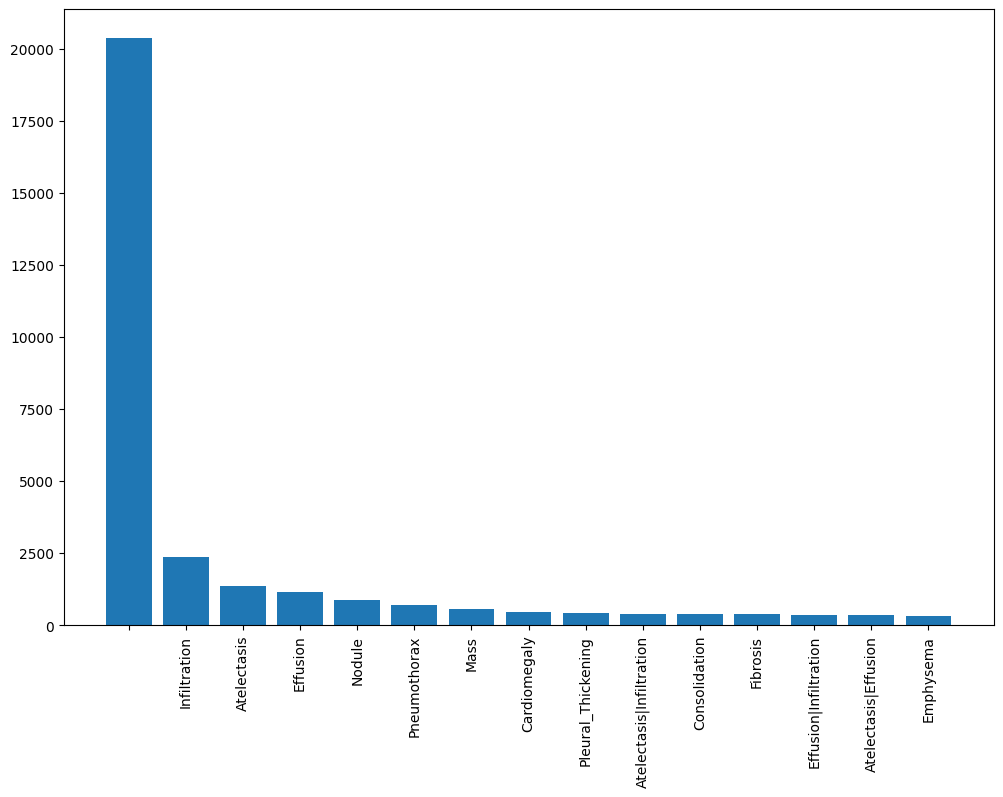

In [173]:
label_counts = csv['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts))+0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts))+0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

In [174]:
sample_weights = csv['Finding Labels'].map(lambda x: len(x.split('|')) if len(x)>0 else 0).values + 4e-2
sample_weights /= sample_weights.sum()

# # If you want to see the weight of each row:
# for index, weight in enumerate(sample_weights):
#   print(f"Row {index}| Weight: {weight}")
# print(f"Length of sample weights: {len(sample_weights)}")
# print(f"Number of rows in dataset: {csv.shape[0]}")

csv = csv.sample(csv.shape[0] // 2, weights=sample_weights)

### Distribution after resampling

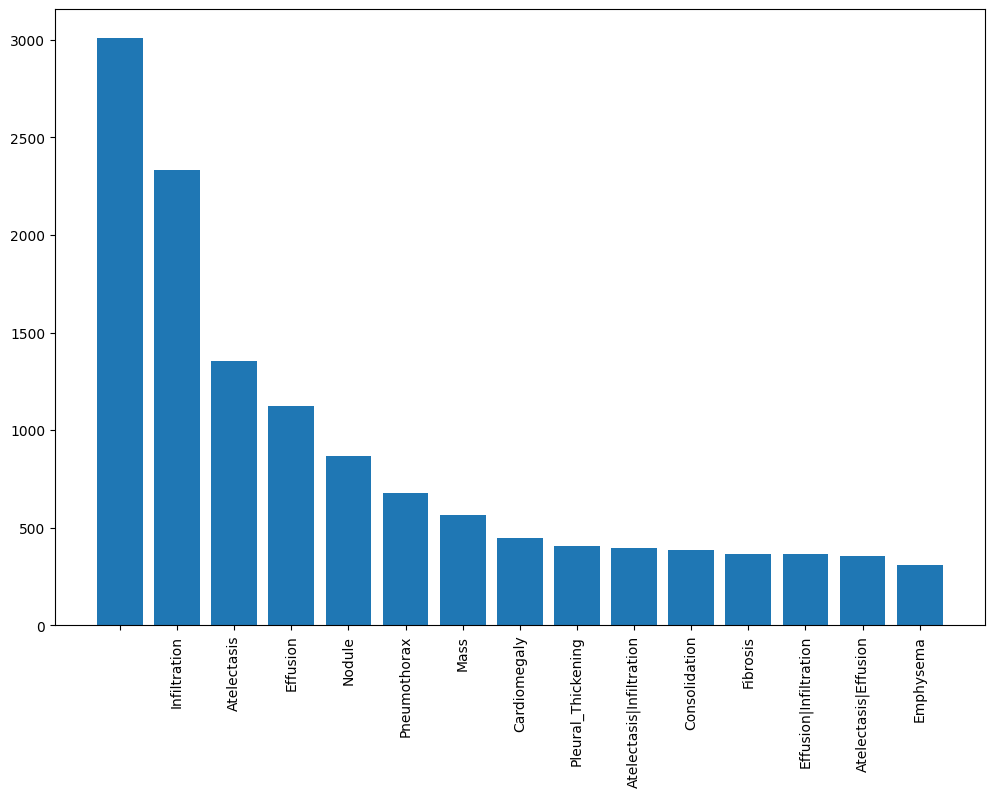

In [175]:
label_counts = csv['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts))+0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts))+0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

## Create a column containing the diseases as a list


In [178]:
csv['disease_vec'] = csv.apply(lambda x: [x[all_labels].values], 1).map(lambda x: x[0])
print(csv["disease_vec"])

5117     [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
14080    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1332     [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
2704     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
10039    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]
                            ...                    
18515    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
32171    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
24800    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
12599    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
22932    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Name: disease_vec, Length: 17499, dtype: object


## Split the dataset

In [190]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(csv,
                                   test_size = 0.10,
                                   random_state = 86196,
                                   stratify = csv['Finding Labels'].map(lambda x: x[:4]))

train_df, valid_df = train_test_split(train_df,
                                   test_size = 0.10,
                                   random_state = 47941,
                                   stratify = train_df['Finding Labels'].map(lambda x: x[:4]))

print('Train:', train_df.shape[0], 'Validation:', valid_df.shape[0], 'Test:', test_df.shape[0])

Train: 14174 Validation: 1575 Test: 1750
